In [1]:
import pandas as pd

# Load the Excel data
file_path = 'C://Users//Anika//EduFundAI/Helb Financing Data.xlsx'
scholarship_data = pd.read_excel(file_path, sheet_name=' Scholarship Data')

# Clean column names and drop rows with missing data
scholarship_data.columns = [col.strip() for col in scholarship_data.columns]
scholarship_data.dropna(subset=['County', 'Scholarship Awards', 'Scholarship Amount'], inplace=True)

# Convert 'County' to string
scholarship_data['County'] = scholarship_data['County'].astype(str)


### Bar Chart (Interactive) ###

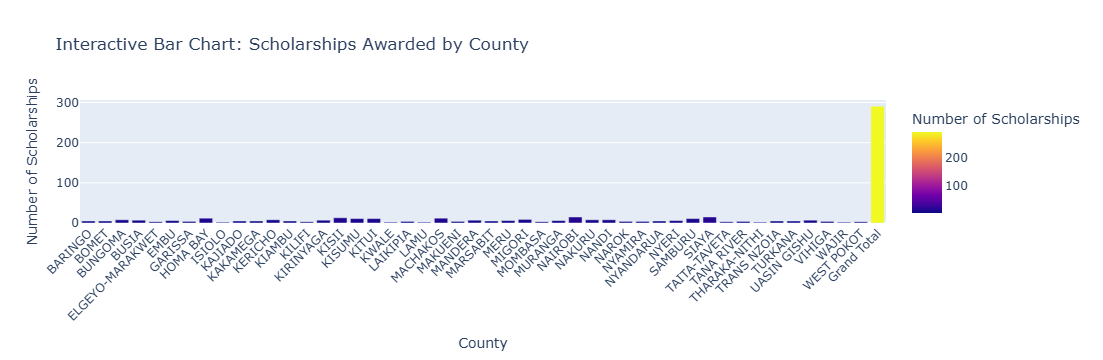

In [2]:
import plotly.express as px

fig = px.bar(
    scholarship_data,
    x='County',
    y='Scholarship Awards',
    color='Scholarship Awards',
    hover_data=['Scholarship Amount'],
    labels={'Scholarship Awards': 'Number of Scholarships'},
    title='Interactive Bar Chart: Scholarships Awarded by County'
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()


### Business Questions ####

1. 
   This wil help to prioritize regions for future funding.

2. Is there a correlation between the number of scholarships awarded and the total amount distributed in each county?
   This can reveal insights into equitable distribution and whether some counties get smaller/larger awards on average.

3. What is the average scholarship amount per award by county?
   This will help to assess the generosity of awards in different regions.

4.

In [2]:
import pandas as pd

# Load the Excel data
file_path = 'C://Users//Anika//EduFundAI/Helb Financing Data.xlsx'
scholarship_data = pd.read_excel(file_path, sheet_name=' Scholarship Data')

# Clean and prepare
scholarship_data.columns = [col.strip() for col in scholarship_data.columns]
scholarship_data.dropna(subset=['County', 'Scholarship Awards', 'Scholarship Amount'], inplace=True)
scholarship_data['County'] = scholarship_data['County'].astype(str)


### Which counties receive the highest number of scholarships, and how does that relate to the total scholarship amount distributed? ###

### Prioritize regions for future funding ### 

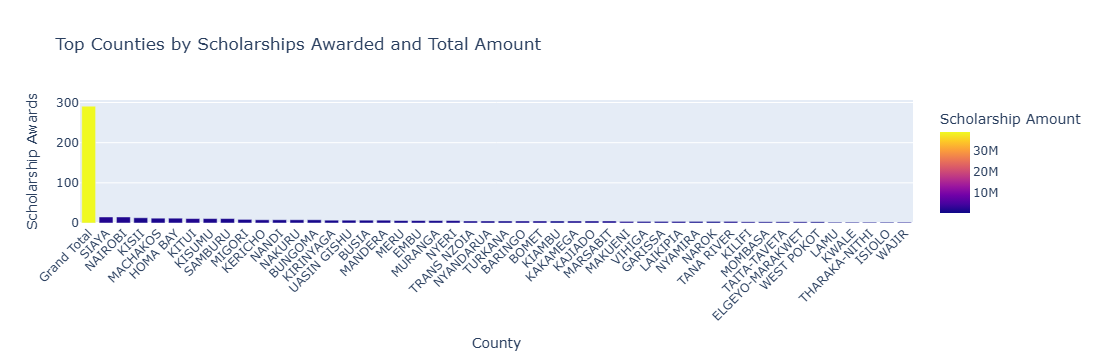

In [3]:
import plotly.express as px

top_counties = scholarship_data.sort_values('Scholarship Awards', ascending=False)

fig = px.bar(
    top_counties,
    x='County',
    y='Scholarship Awards',
    color='Scholarship Amount',
    hover_data=['Scholarship Amount'],
    title='Top Counties by Scholarships Awarded and Total Amount'
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()


### Is there a correlation between the number of scholarships awarded and the total amount distributed in each county? ###

### Reveal insights into equitable distribution and whether some counties get smaller/larger awards on average ###

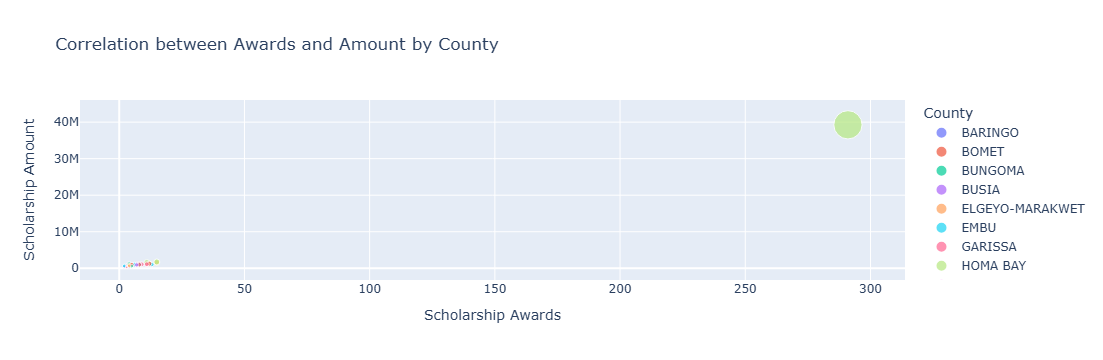

In [4]:
fig = px.scatter(
    scholarship_data,
    x='Scholarship Awards',
    y='Scholarship Amount',
    color='County',
    size='Scholarship Amount',
    hover_name='County',
    title='Correlation between Awards and Amount by County'
)
fig.show()


###  What is the average scholarship amount per award by county? ###

###  Assess the generosity of awards in different regions ###

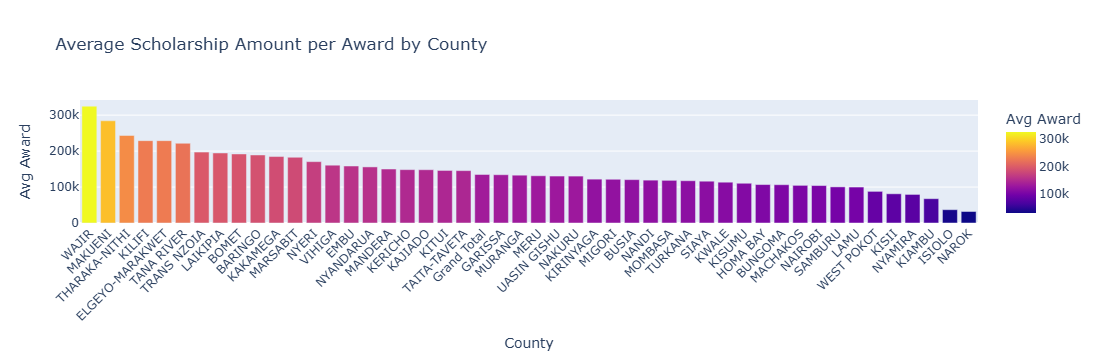

In [5]:
scholarship_data['Avg Award'] = scholarship_data['Scholarship Amount'] / scholarship_data['Scholarship Awards']

fig = px.bar(
    scholarship_data.sort_values('Avg Award', ascending=False),
    x='County',
    y='Avg Award',
    color='Avg Award',
    title='Average Scholarship Amount per Award by County'
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()


### Which counties receive the largest share of the total scholarship funds? ###

### Identify funding concentration and potential areas for balancing support  ###

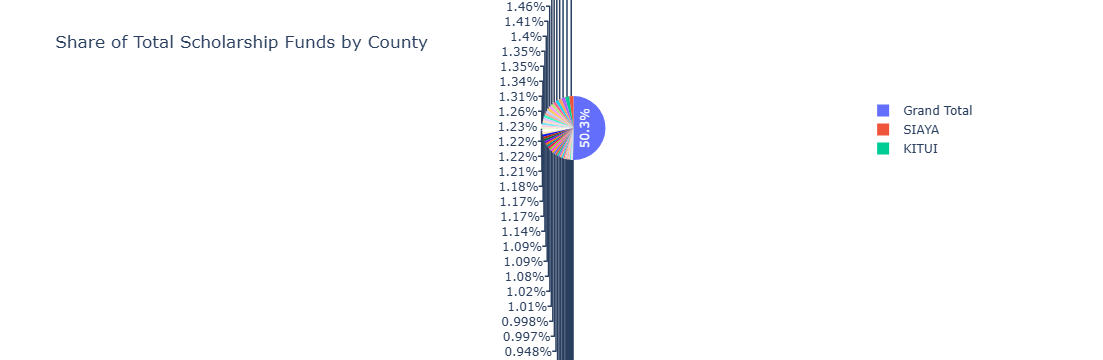

In [6]:
fig = px.pie(
    scholarship_data,
    names='County',
    values='Scholarship Amount',
    title='Share of Total Scholarship Funds by County'
)
fig.show()


### Estimate future scholarship needs by County, based on the data ###

### Model Target ###

Predict the number of scholarships awarded for each county in the next year (or next cycle).

In [7]:
import numpy as np
import pandas as pd

# Load the Excel data
file_path = 'C://Users//Anika//EduFundAI/Helb Financing Data.xlsx'
scholarship_data = pd.read_excel(file_path, sheet_name=' Scholarship Data')
scholarship_data.columns = [col.strip() for col in scholarship_data.columns]
scholarship_data.dropna(subset=['County', 'Scholarship Awards', 'Scholarship Amount'], inplace=True)
scholarship_data['County'] = scholarship_data['County'].astype(str)

# Simulate Year data
years = [2019, 2020, 2021, 2022, 2023]
simulated_data = pd.DataFrame()

for year in years:
    temp = scholarship_data.copy()
    temp['Year'] = year
    # Simulate trends (add small random noise)
    temp['Scholarship Awards'] += np.random.randint(-2, 3, size=temp.shape[0])
    simulated_data = pd.concat([simulated_data, temp], ignore_index=True)

print(simulated_data.head())


            County  Scholarship Awards  Scholarship Amount  Year
0          BARINGO                 7.0            946000.0  2019
1            BOMET                 3.0            960091.0  2019
2          BUNGOMA                 8.0            852000.0  2019
3            BUSIA                 6.0            844000.0  2019
4  ELGEYO-MARAKWET                 5.0            687000.0  2019


### Visualize Trend Over Time ###

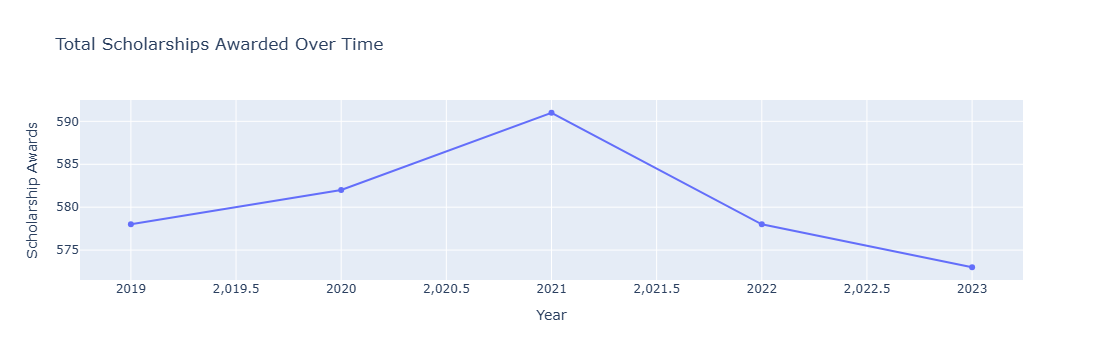

In [8]:
import plotly.express as px

fig = px.line(
    simulated_data.groupby(['Year'])['Scholarship Awards'].sum().reset_index(),
    x='Year',
    y='Scholarship Awards',
    title='Total Scholarships Awarded Over Time',
    markers=True
)
fig.show()


### Build Predictive Model ###

In [9]:
from sklearn.linear_model import LinearRegression

# Aggregate data by Year
yearly_data = simulated_data.groupby('Year')['Scholarship Awards'].sum().reset_index()

# Train Linear Regression Model
X = yearly_data[['Year']]
y = yearly_data['Scholarship Awards']

model = LinearRegression()
model.fit(X, y)

# Predict future year (e.g. 2024)
future_year = pd.DataFrame({'Year': [2024]})
predicted_awards = model.predict(future_year)

print(f"Predicted Scholarship Awards for 2024: {int(predicted_awards[0])}")


Predicted Scholarship Awards for 2024: 576
